In [4]:
# introduce this script
# This script is used to parse the JSON data from discourse graphs and plot the nodes as a graph.
# written by GPT4o 8/2024

import json
import networkx as nx
import matplotlib.pyplot as plt

def load_json(file_path):
    """Load and parse the JSON file.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        dict: The parsed JSON data.
    """
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def parse_nodes(nodes):
    """Parse and process the nodes.

    Args:
        nodes (list): The list of node objects.

    Returns:
        dict: A dictionary containing parsed node data.
    """
    node_dict = {}
    for node in nodes:
        uid = node.get('uid')
        title = node.get('title')
        children = node.get('children', [])
        node_dict[uid] = {
            'title': title,
            'children': [child.get('uid') for child in children],
            'details': node
        }
    return node_dict

def parse_relations(relations):
    """Parse and process the relations.

    Args:
        relations (list): The list of relation objects.

    Returns:
        list: A list of dictionaries containing parsed relation data.
    """
    relation_dict = []
    for relation in relations:
        relation_dict.append({
            'label': relation.get('label'),
            'source': relation.get('source'),
            'target': relation.get('target')
        })
    return relation_dict

def parse_grammar(grammar):
    """Parse and process the grammar section.

    Args:
        grammar (list): The list of grammar objects.

    Returns:
        list: A list of dictionaries containing parsed grammar data.
    """
    grammar_dict = []
    for item in grammar:
        grammar_dict.append({
            'label': item.get('label'),
            'source': item.get('source'),
            'destination': item.get('destination')
        })
    return grammar_dict

def main(file_path):
    """Main function to load and parse the JSON data.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        tuple: A tuple containing the parsed nodes, relations, and grammar sections.
    """
    # Load and parse the JSON data
    data = load_json(file_path)
    
    # Parse nodes, relations, and grammar sections
    nodes = parse_nodes(data.get('nodes', []))
    relations = parse_relations(data.get('relations', []))
    grammar = parse_grammar(data.get('grammar', []))
    
    return nodes, relations, grammar


def create_graph(nodes, relations):
    """Create a graph from nodes and relations."""
    G = nx.DiGraph()
    
    # Add nodes
    for uid, node_info in nodes.items():
        title = node_info['title']
        G.add_node(uid, label=title)
    
    # Add edges
    for relation in relations:
        source = relation['source']
        target = relation['target']
        label = relation['label']
        G.add_edge(source, target, label=label)
    
    return G

def draw_graph(G):
    """Draw the graph with networkx and matplotlib."""
    pos = nx.spring_layout(G)
    labels = nx.get_node_attributes(G, 'label')
    edge_labels = nx.get_edge_attributes(G, 'label')
    
    plt.figure(figsize=(12, 12))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=7000, node_color='lightblue', alpha=0.9)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edgelist=G.edges, arrowstyle='->', arrowsize=20, edge_color='gray')
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color='black')
    
    # Draw edge labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.5)
    
    plt.title("Visualization of JSON Data Structure", fontsize=16)
    plt.axis('off')
    plt.show()

def draw_graph_with_custom_colors(G, nodes):
    """Draw the graph with custom colors based on the provided image."""
    pos = nx.spring_layout(G, k=0.5, seed=42)
    
    # Define custom colors based on the image reference
    color_scheme = {
        'Claim': '#4CAF50',  # Green for claims
        'Evidence': '#F44336',  # Red for evidence
        'Question': '#FFEB3B',  # Yellow/Orange for questions
        'Default': 'lightgray'  # Default color for others
    }
    
    node_colors = []
    node_sizes = []
    for uid, data in nodes.items():
        title = data['title']
        if 'CLM' in title:
            node_colors.append(color_scheme['Claim'])
        elif 'QUE' in title:
            node_colors.append(color_scheme['Question'])
        elif 'EVD' in title:
            node_colors.append(color_scheme['Evidence'])
        else:
            node_colors.append(color_scheme['Default'])
        
        # Node size based on the degree of the node
        node_sizes.append(3000 + 1000 * G.degree[uid])
    
    labels = nx.get_node_attributes(G, 'label')
    edge_labels = nx.get_edge_attributes(G, 'label')
    
    plt.figure(figsize=(16, 16))
    
    # Draw nodes with custom colors and varying sizes
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
    
    # Draw edges with varying thickness and color
    nx.draw_networkx_edges(G, pos, edgelist=G.edges, arrowstyle='->', arrowsize=20, edge_color='gray', width=2)
    
    # Draw labels on nodes
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_color='black')
    
    # Draw edge labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, label_pos=0.5, font_color='darkblue')
    
    # Add a title
    plt.title("Custom Color Scheme: Visualization of JSON Data Structure", fontsize=18)
    plt.axis('off')
    
    # Create a legend based on the custom color scheme
    plt.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', label='Claim', markerfacecolor=color_scheme['Claim'], markersize=15),
        plt.Line2D([0], [0], marker='o', color='w', label='Question', markerfacecolor=color_scheme['Question'], markersize=15),
        plt.Line2D([0], [0], marker='o', color='w', label='Evidence', markerfacecolor=color_scheme['Evidence'], markersize=15),
    ], loc="upper right", fontsize=12)
    
    plt.show()


In [5]:
# Specify the file path
file_path = 'akamatsulab_cheetah_example_json_202408151251.json'
nodes, relations, grammar = main(file_path)

nodes, relations, grammar[:5]  # Display the parsed data (with a limit for grammar section)


({'doLu5PTIu': {'title': '[[CLM]] - Cheetahs are the fastest land animal',
   'children': ['0XcCTBfgE', 'XRW8dMSMw'],
   'details': {'uid': 'doLu5PTIu',
    'title': '[[CLM]] - Cheetahs are the fastest land animal',
    'children': [{'text': 'Source of Claim',
      'open': True,
      'order': 0,
      'uid': '0XcCTBfgE',
      'heading': 2,
      'viewType': 'bullet',
      'editTime': '2023-05-29T21:54:24.600Z',
      'props': {'imageResize': {}, 'iframe': {}},
      'textAlign': 'left',
      'children': [],
      'parents': []},
     {'text': 'Notes',
      'open': True,
      'order': 1,
      'uid': 'XRW8dMSMw',
      'heading': 2,
      'viewType': 'bullet',
      'editTime': '2023-05-29T21:54:24.605Z',
      'props': {'imageResize': {}, 'iframe': {}},
      'textAlign': 'left',
      'children': [],
      'parents': []}],
    'date': '2023-05-29T21:54:24.227Z',
    'createdBy': 'Matt Akamatsu'}},
  'cyQikwNB-': {'title': '[[QUE]] - What is the fastest land animal?',
   'childr

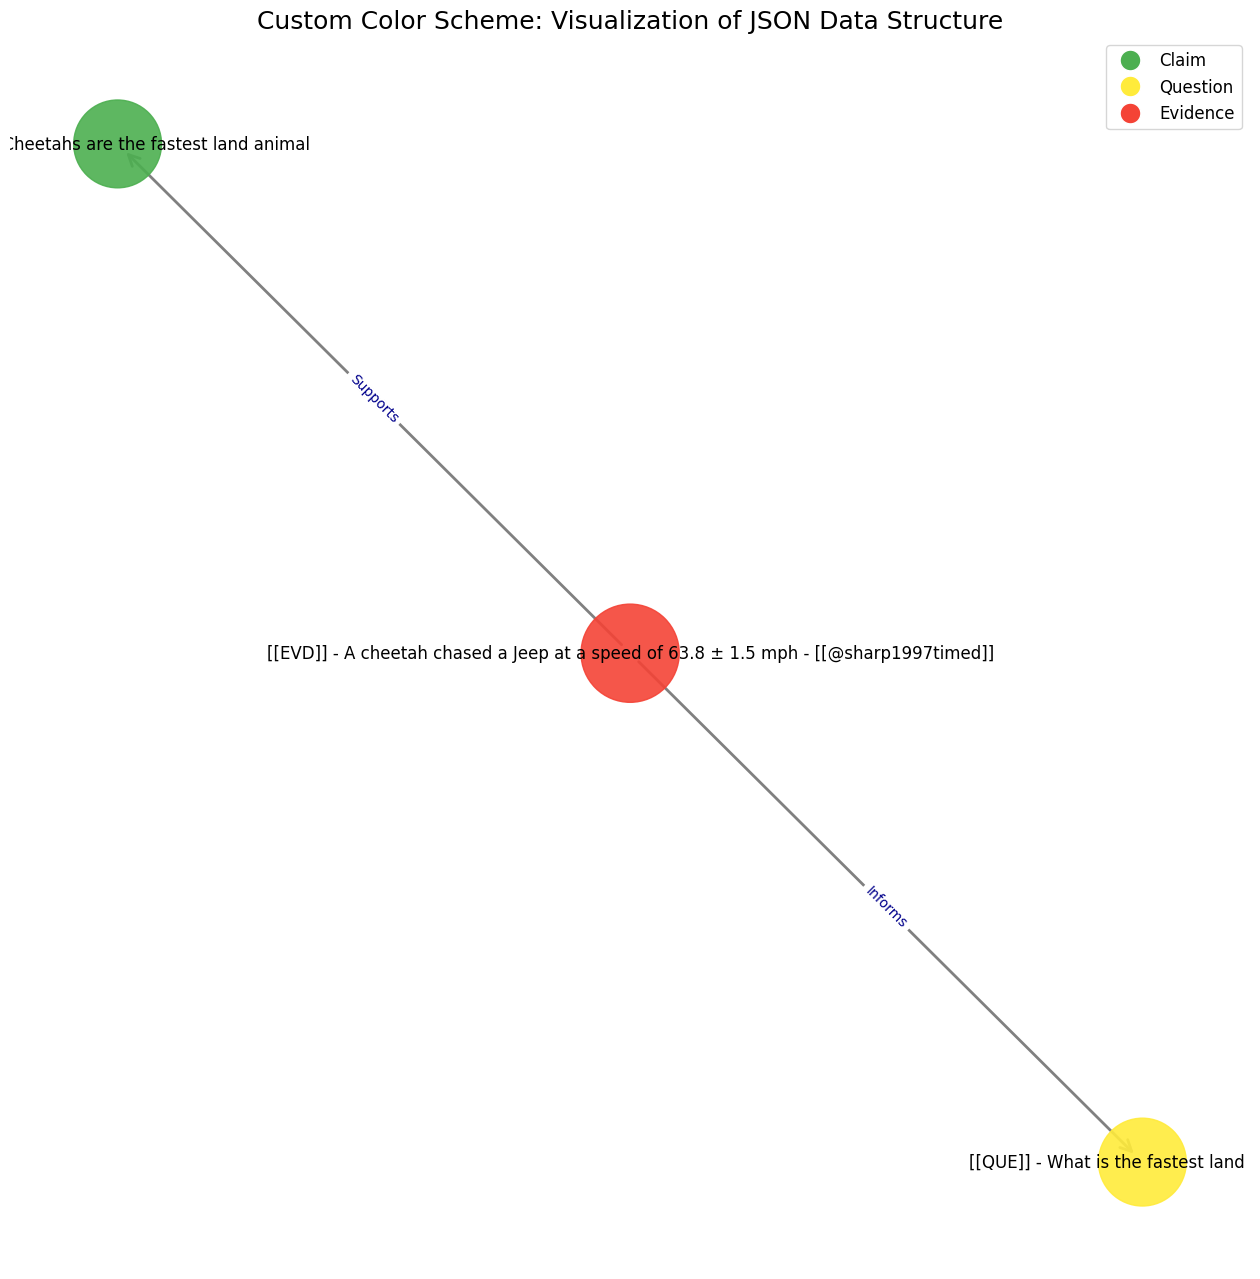

In [6]:
# Create the graph from parsed data
G = create_graph(nodes, relations)

# Draw the graph
# draw_graph(G)

# Draw the graph with the custom color scheme
draw_graph_with_custom_colors(G, nodes)

